# Detective Case Language Analyzer

### Natural Language Processing - CA1 Mini Project

This project implements a rule-based NLP system for understanding
simple detective investigation statements.

The system performs:

- Tokenization
- Sentence validation
- Rejection reason identification
- Subject identification
- Verb identification
- Object identification
- Simple parsing

## Problem Statement

The project defines a small controlled language consisting of simple
English sentences related to detective investigations.

Each valid sentence follows the basic:

Subject + Verb + Object

structure.

The system accepts or rejects a given sentence.

For an accepted sentence, the system identifies the role of each word
as Subject, Verb or Object.

For a rejected sentence, the system provides an appropriate reason
for rejection.

## Objective

The objectives of this project are:

1. To create a corpus of 20 detective investigation sentences.
2. To tokenize input sentences.
3. To validate whether a sentence follows the defined language.
4. To identify invalid words or sentence structures.
5. To identify Subject, Verb and Object roles.
6. To perform simple parsing using the SVO structure.
7. To provide meaningful rejection reasons.
8. To demonstrate basic Natural Language Processing concepts using Python.

Step 1 — Import Libraries

Explanation:

We use Python libraries to organize and analyze our corpus.
Pandas is used for tabular data, while Matplotlib is used for visualization

In [70]:
import pandas as pd
import matplotlib.pyplot as plt

Step 2 - Create Corpus

Explanation:

A corpus is a collection of sentences used by an NLP system.
Our corpus contains 20 simple detective investigation sentences.

In [71]:
corpus = [
    "Detective finds clue",
    "Detective questions suspect",
    "Detective follows suspect",
    "Detective checks room",
    "Officer finds evidence",
    "Officer checks room",
    "Officer examines scene",
    "Officer tracks vehicle",
    "Witness reports crime",
    "Witness observes suspect",
    "Witness reports evidence",
    "Inspector examines clue",
    "Inspector searches room",
    "Inspector collects evidence",
    "Agent follows suspect",
    "Agent tracks vehicle",
    "Agent checks document",
    "Guard observes scene",
    "Guard finds footprint",
    "Guard checks vehicle"
]

print("Number of sentences in corpus:", len(corpus))

Number of sentences in corpus: 20


Step 3 - Define Vocabulary

Explanation:

We define separate lists for Subjects, Verbs, and Objects.
These words form the basic vocabulary of our controlled detective language.

In [72]:
subjects = [
    "Detective",
    "Officer",
    "Witness",
    "Inspector",
    "Agent",
    "Guard"
]

verbs = [
    "finds",
    "questions",
    "reports",
    "follows",
    "checks",
    "examines",
    "searches",
    "collects",
    "observes",
    "tracks"
]

objects = [
    "clue",
    "suspect",
    "evidence",
    "crime",
    "room",
    "witness",
    "scene",
    "footprint",
    "document",
    "vehicle"
]

print("Subjects:", subjects)
print("Verbs:", verbs)
print("Objects:", objects)

Subjects: ['Detective', 'Officer', 'Witness', 'Inspector', 'Agent', 'Guard']
Verbs: ['finds', 'questions', 'reports', 'follows', 'checks', 'examines', 'searches', 'collects', 'observes', 'tracks']
Objects: ['clue', 'suspect', 'evidence', 'crime', 'room', 'witness', 'scene', 'footprint', 'document', 'vehicle']


Step 4 — Tokenization

Explanation:

Tokenization breaks a sentence into individual words called tokens.
For example, "Detective finds clue" becomes three tokens.

In [73]:
def tokenize(sentence):
    return sentence.strip().split()

Step 5 — Sentence Validation

Explanation:

This step checks whether the input contains a valid Subject, Verb, and Object.
If any word is invalid, the system provides a specific rejection reason.

In [74]:
def validate_sentence(sentence):

    tokens = tokenize(sentence)

    if len(tokens) != 3:
        return False, "Sentence must contain exactly three words."

    subject = tokens[0]
    verb = tokens[1]
    object_word = tokens[2]

    if subject.lower() not in [s.lower() for s in subjects]:
        return False, f"'{subject}' is not a valid subject."

    if verb.lower() not in [v.lower() for v in verbs]:
        return False, f"'{verb}' is not a valid detective action."

    if object_word.lower() not in [o.lower() for o in objects]:
        return False, f"'{object_word}' is not a valid investigation object."

    return True, "Sentence follows the defined language structure."

Step 5.1 — Test Valid Sentence

Explanation:

We test the validator with a sentence containing valid Subject, Verb, and Object words.
The system should accept the sentence.

In [75]:
result, reason = validate_sentence("Detective finds clue")

print("Accepted:", result)
print("Reason:", reason)

Accepted: True
Reason: Sentence follows the defined language structure.


Step 5.2 — Test Invalid Verb

Explanation:

Here we test a sentence containing an action that is not defined in our detective language.
The system should reject it and explain that the verb is invalid.

In [76]:
result, reason = validate_sentence("Detective eats evidence")

print("Accepted:", result)
print("Reason:", reason)

Accepted: False
Reason: 'eats' is not a valid detective action.


Step 5.3 — Test Invalid Subject

Explanation:

This test checks whether the first word belongs to our defined Subject vocabulary.
"Teacher" is not included, so the sentence is rejected.

In [77]:
result, reason = validate_sentence("Teacher finds clue")

print("Accepted:", result)
print("Reason:", reason)

Accepted: False
Reason: 'Teacher' is not a valid subject.


Step 5.4 — Test Invalid Object

Explanation:

This test checks whether the object is valid for our controlled language.
"Pizza" is not an investigation object in our corpus, so the sentence is rejected.

In [78]:
result, reason = validate_sentence("Detective finds pizza")

print("Accepted:", result)
print("Reason:", reason)

Accepted: False
Reason: 'pizza' is not a valid investigation object.


Step 6 — Role Identification

Explanation:

After accepting a sentence, we identify the role of each word.
In our simple SVO structure, the first word is Subject, second is Verb, and third is Object.

In [79]:
def identify_roles(sentence):

    tokens = tokenize(sentence)

    roles = {}

    for index, word in enumerate(tokens):

        if index == 0:
            roles[word] = "Subject"

        elif index == 1:
            roles[word] = "Verb"

        elif index == 2:
            roles[word] = "Object"

    return roles

Step 6.1 — Test Role Identification

Explanation:

We test the role identification function using a valid detective sentence.
The output shows the grammatical role assigned to each token.

In [80]:
roles = identify_roles("Detective finds clue")

for word, role in roles.items():
    print(f"{word} -> {role}")

Detective -> Subject
finds -> Verb
clue -> Object


Step 7 — Simple Parsing

Explanation:

Parsing identifies the basic structure of a sentence.
Our parser represents each sentence using the Subject-Verb-Object structure.

In [81]:
def parse_sentence(sentence):

    tokens = tokenize(sentence)

    if len(tokens) != 3:
        return None

    return {
        "Subject": tokens[0],
        "Verb": tokens[1],
        "Object": tokens[2]
    }

Step 7.1 — Test Parsing

Explanation:

We test the parser with a valid sentence.
The output shows the Subject, Verb, and Object separately.

In [82]:
parsed = parse_sentence("Detective finds clue")

print(parsed)

{'Subject': 'Detective', 'Verb': 'finds', 'Object': 'clue'}


Step 8 — Complete Analyzer

Explanation:

This function combines all the main NLP steps into one system.
It validates the sentence and, if accepted, displays tokens, roles, and the parsed structure.

In [83]:
def analyze_sentence(sentence):

    print("Input:", sentence)
    print()

    accepted, reason = validate_sentence(sentence)

    if not accepted:
        print("Status: REJECTED ✗")
        print("Reason:", reason)
        return

    print("Status: ACCEPTED ✓")
    print("Reason:", reason)
    print()

    tokens = tokenize(sentence)

    print("Tokens:", tokens)
    print()

    roles = identify_roles(sentence)

    print("Word Roles:")

    for word, role in roles.items():
        print(f"{word} -> {role}")

    print()

    parsed = parse_sentence(sentence)

    print("Parse:")
    print(parsed)

Step 8.1 — Final Accepted Demo

Explanation:

This is a complete demonstration using a valid detective sentence.
The system accepts the sentence and identifies its Subject, Verb, and Object.

In [84]:
analyze_sentence("Detective finds clue")

Input: Detective finds clue

Status: ACCEPTED ✓
Reason: Sentence follows the defined language structure.

Tokens: ['Detective', 'finds', 'clue']

Word Roles:
Detective -> Subject
finds -> Verb
clue -> Object

Parse:
{'Subject': 'Detective', 'Verb': 'finds', 'Object': 'clue'}


Step 8.2 — Final Rejected Demo

Explanation:

This demonstrates how the system handles an invalid sentence.
Since "eats" is not a defined detective action, the sentence is rejected with a reason.

In [85]:
analyze_sentence("Detective eats evidence")

Input: Detective eats evidence

Status: REJECTED ✗
Reason: 'eats' is not a valid detective action.


Step 8.3 — Multiple Test Cases

Explanation:

We test the system with several valid and invalid sentences.
This helps demonstrate that the analyzer works for different types of inputs.

In [86]:
test_sentences = [
    "Detective finds clue",
    "Officer examines scene",
    "Witness reports crime",
    "Agent tracks vehicle",
    "Detective eats evidence",
    "Teacher finds clue",
    "Detective finds pizza",
    "Detective finds",
    "Guard observes scene"
]

for sentence in test_sentences:

    analyze_sentence(sentence)

    print("=" * 60)

Input: Detective finds clue

Status: ACCEPTED ✓
Reason: Sentence follows the defined language structure.

Tokens: ['Detective', 'finds', 'clue']

Word Roles:
Detective -> Subject
finds -> Verb
clue -> Object

Parse:
{'Subject': 'Detective', 'Verb': 'finds', 'Object': 'clue'}
Input: Officer examines scene

Status: ACCEPTED ✓
Reason: Sentence follows the defined language structure.

Tokens: ['Officer', 'examines', 'scene']

Word Roles:
Officer -> Subject
examines -> Verb
scene -> Object

Parse:
{'Subject': 'Officer', 'Verb': 'examines', 'Object': 'scene'}
Input: Witness reports crime

Status: ACCEPTED ✓
Reason: Sentence follows the defined language structure.

Tokens: ['Witness', 'reports', 'crime']

Word Roles:
Witness -> Subject
reports -> Verb
crime -> Object

Parse:
{'Subject': 'Witness', 'Verb': 'reports', 'Object': 'crime'}
Input: Agent tracks vehicle

Status: ACCEPTED ✓
Reason: Sentence follows the defined language structure.

Tokens: ['Agent', 'tracks', 'vehicle']

Word Roles:
Ag

Step 9 — Corpus DataFrame

Explanation:

We convert our corpus into a table to make the dataset easier to inspect.
Each sentence is divided into its Subject, Verb, and Object.

In [87]:
data = []

for sentence in corpus:

    tokens = tokenize(sentence)

    data.append({
        "Sentence": sentence,
        "Subject": tokens[0],
        "Verb": tokens[1],
        "Object": tokens[2]
    })

df = pd.DataFrame(data)

df

,Sentence,Subject,Verb,Object
0,Detective finds clue,Detective,finds,clue
1,Detective questions suspect,Detective,questions,suspect
2,Detective follows suspect,Detective,follows,suspect
3,Detective checks room,Detective,checks,room
4,Officer finds evidence,Officer,finds,evidence
5,Officer checks room,Officer,checks,room
6,Officer examines scene,Officer,examines,scene
7,Officer tracks vehicle,Officer,tracks,vehicle
8,Witness reports crime,Witness,reports,crime
9,Witness observes suspect,Witness,observes,suspect


Step 10 — Corpus Analysis

Explanation:

We count how frequently each detective action appears in our corpus.
This gives us a simple statistical observation about our dataset.

In [88]:
verb_counts = df["Verb"].value_counts()

print(verb_counts)

Verb
checks       4
finds        3
follows      2
examines     2
tracks       2
reports      2
observes     2
questions    1
searches     1
collects     1
Name: count, dtype: int64


Step 10.1 — Visualization

Explanation:

The bar chart visualizes the frequency of different actions in the corpus.
This makes the corpus analysis easier to understand.

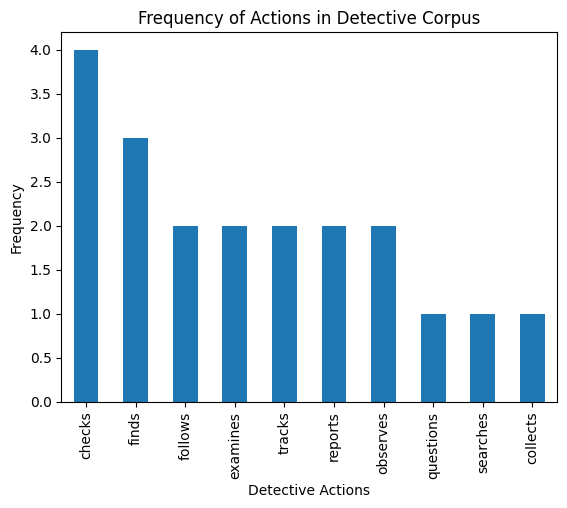

In [89]:
verb_counts.plot(
    kind="bar",
    title="Frequency of Actions in Detective Corpus",
    xlabel="Detective Actions",
    ylabel="Frequency"
)

plt.show()

Step 11 — Subject Frequency

Explanation:

This step counts how many times each subject appears in our detective corpus.
It helps us understand the distribution of different participants in the sentences.

In [90]:
subject_counts = df["Subject"].value_counts()

print(subject_counts)

Subject
Detective    4
Officer      4
Witness      3
Inspector    3
Agent        3
Guard        3
Name: count, dtype: int64


Step 11.1 — Subject Frequency Visualization

Explanation:

This step represents the subject frequencies using a bar chart.
The chart makes it easier to compare how frequently each subject occurs in the corpus.

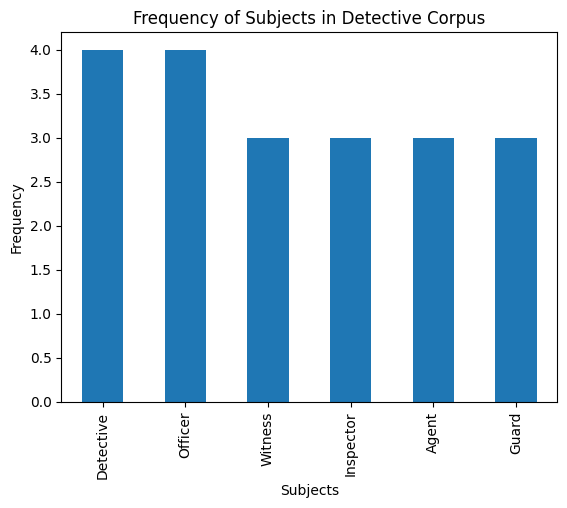

In [91]:
subject_counts.plot(
    kind="bar",
    title="Frequency of Subjects in Detective Corpus",
    xlabel="Subjects",
    ylabel="Frequency"
)

plt.show()

Step 12 — Interactive Input

Explanation:

Finally, the user can enter their own detective sentence.
The analyzer processes the sentence and displays whether it is accepted or rejected.

In [92]:
user_sentence = input("Enter a detective case sentence: ")

analyze_sentence(user_sentence)

Input: 

Status: REJECTED ✗
Reason: Sentence must contain exactly three words.
